# 스파이크: 프로젝트 완주 가능성 검증

목적: Phase 순서와 무관하게, "데이터 → 전처리 → 모델 → SHAP 설명 → 승인 임계값" 전체 파이프라인이
막힘없이 끝까지 돌아가는지 최소 구현으로 한 번에 확인한다. 여기서 나온 전처리 방식·하이퍼파라미터는
가안일 뿐 최종안이 아니다(전처리는 Phase 2, 모델 튜닝은 Phase 3, SHAP 사유 코드 설계는 Phase 4에서 별도로 정한다).

확인 항목:
1. `cs-training.csv` 로드, 타깃 비율·결측·이상치 실제 수치 확인 (CLAUDE.md 데이터 주의사항 대조)
2. 최소 전처리 (결측 중앙값 대체, 96/98 코드값 처리, 극단값 클리핑)
3. 로지스틱 회귀 베이스라인 → AUC
4. XGBoost 기본값 + `scale_pos_weight` → AUC, 베이스라인과 비교
5. SHAP TreeExplainer — 전역 중요도, 개별 고객 1명 상위 기여 변수
6. 임계값별 승인율 vs 승인자 부실률 표
7. 각 단계 실행 시간


In [1]:
import time
from contextlib import contextmanager

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
plt.rcParams["font.family"] = "AppleGothic"  # 그래프 한글 라벨 깨짐 방지 (macOS)
plt.rcParams["axes.unicode_minus"] = False

RANDOM_STATE = 42
DATA_DIR = "../../data/raw"
TARGET = "SeriousDlqin2yrs"
DELINQ_COLS = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
]

timings = {}


@contextmanager
def timer(step_name):
    start = time.perf_counter()
    yield
    elapsed = time.perf_counter() - start
    timings[step_name] = elapsed
    print(f"[{step_name}] {elapsed:.2f}초")


/Users/gene/creditLens/ml/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. 데이터 로드 및 실제 수치 확인

CLAUDE.md에 적힌 데이터 주의사항이 실제 수치와 맞는지 하나씩 대조한다.

In [2]:
with timer("데이터 로드"):
    train = pd.read_csv(f"{DATA_DIR}/cs-training.csv", index_col=0)

print("shape:", train.shape)
train.head()


[데이터 로드] 0.05초
shape: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
with timer("데이터 점검"):
    n = len(train)
    target_rate = train[TARGET].mean()

    income_missing_rate = train["MonthlyIncome"].isna().mean()
    dependents_missing_rate = train["NumberOfDependents"].isna().mean()

    code_mask = (train[DELINQ_COLS] >= 96).any(axis=1)
    code_rows = int(code_mask.sum())

    util_over1 = (train["RevolvingUtilizationOfUnsecuredLines"] > 1).sum()

    income_missing_or_zero = train["MonthlyIncome"].isna() | (train["MonthlyIncome"] == 0)
    debtratio_when_income_bad = train.loc[income_missing_or_zero, "DebtRatio"].median()
    debtratio_when_income_ok = train.loc[~income_missing_or_zero, "DebtRatio"].median()

    age_zero = int((train["age"] <= 0).sum())

checks = pd.DataFrame(
    [
        ("타깃 양성 비율", f"{target_rate:.2%}", "CLAUDE.md: 약 7%"),
        ("MonthlyIncome 결측률", f"{income_missing_rate:.2%}", "CLAUDE.md: 약 20%"),
        ("NumberOfDependents 결측 존재", f"{dependents_missing_rate:.2%}", "CLAUDE.md: 일부 결측"),
        ("연체 변수 96/98 코드값 행 수", f"{code_rows:,}건", "CLAUDE.md: 존재한다고만 명시"),
        ("RevolvingUtilization 1 초과 행 수", f"{util_over1:,}건", "CLAUDE.md: 1 크게 초과 값 존재"),
        ("소득 결측·0일 때 DebtRatio 중앙값", f"{debtratio_when_income_bad:,.1f}", "CLAUDE.md: 비정상적으로 큼"),
        ("정상 소득일 때 DebtRatio 중앙값", f"{debtratio_when_income_ok:,.3f}", "비교 기준"),
        ("age <= 0 행 수", f"{age_zero}건", "CLAUDE.md: 0인 행 존재"),
    ],
    columns=["항목", "실제 수치", "CLAUDE.md 서술"],
)
checks


[데이터 점검] 0.00초


,항목,실제 수치,CLAUDE.md 서술
0,타깃 양성 비율,6.68%,CLAUDE.md: 약 7%
1,MonthlyIncome 결측률,19.82%,CLAUDE.md: 약 20%
2,NumberOfDependents 결측 존재,2.62%,CLAUDE.md: 일부 결측
3,연체 변수 96/98 코드값 행 수,269건,CLAUDE.md: 존재한다고만 명시
4,RevolvingUtilization 1 초과 행 수,"3,321건",CLAUDE.md: 1 크게 초과 값 존재
5,소득 결측·0일 때 DebtRatio 중앙값,"1,144.0",CLAUDE.md: 비정상적으로 큼
6,정상 소득일 때 DebtRatio 중앙값,0.292,비교 기준
7,age <= 0 행 수,1건,CLAUDE.md: 0인 행 존재


→ 위 수치가 모두 CLAUDE.md의 서술과 방향이 일치한다면(비율 근사, "존재함" confirm) 데이터 주의사항은 유효한 것으로 본다.
불일치 항목이 있으면 CLAUDE.md를 갱신해야 한다.


## 2. 최소 전처리

최종 전처리 방침이 아니라 스파이크를 끝까지 돌리기 위한 최소 구현이다(Phase 2에서 재설계).

In [4]:
with timer("전처리"):
    df = train.copy()

    # (1) 96/98 코드값 처리: 연체 변수의 96/98은 정상 범위를 벗어난 코드값이므로 결측으로 간주 후
    #     중앙값으로 채운다 (다른 결측 컬럼과 동일한 방식으로 통일)
    for col in DELINQ_COLS:
        df.loc[df[col] >= 96, col] = np.nan

    # (2) 결측 중앙값 대체: MonthlyIncome, NumberOfDependents, 연체 변수 3개(코드값 제거 후)
    missing_cols = ["MonthlyIncome", "NumberOfDependents"] + DELINQ_COLS
    medians = df[missing_cols].median()
    df[missing_cols] = df[missing_cols].fillna(medians)

    # (3) 극단값 클리핑: 피처 전체를 하한 0.5%, 상한 99.5% 분위수로 winsorize
    feature_cols = [c for c in df.columns if c != TARGET]
    lower = df[feature_cols].quantile(0.005)
    upper = df[feature_cols].quantile(0.995)
    df[feature_cols] = df[feature_cols].clip(lower=lower, upper=upper, axis=1)

print("전처리 후 결측 합계:", df[feature_cols].isna().sum().sum())
df[feature_cols].describe()


[전처리] 0.03초
전처리 후 결측 합계: 0


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,0.322328,52.285793,0.238687,325.217939,6200.663493,8.427433,0.081107,1.007767,0.059593,0.734747
std,0.356769,14.720757,0.647630,955.301614,4134.774785,5.025920,0.382234,1.043331,0.278261,1.093439
min,0.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.029867,41.000000,0.000000,0.175074,3903.000000,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.154181,52.000000,0.000000,0.366508,5400.000000,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.559046,63.000000,0.000000,0.868254,7400.000000,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.366269,89.000000,4.000000,6186.010000,31250.000000,27.000000,3.000000,6.000000,2.000000,5.000000


## 3. 학습/홀드아웃 분할

In [5]:
X = df[feature_cols]
y = df[TARGET]

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("학습:", X_train.shape, "홀드아웃:", X_holdout.shape)
print("학습 타깃 비율:", y_train.mean(), "/ 홀드아웃 타깃 비율:", y_holdout.mean())


학습: (120000, 10) 홀드아웃: (30000, 10)
학습 타깃 비율: 0.06684166666666666 / 홀드아웃 타깃 비율: 0.06683333333333333


## 4. 로지스틱 회귀 베이스라인

In [6]:
with timer("로지스틱 회귀 학습"):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_holdout_scaled = scaler.transform(X_holdout)

    logreg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)
    logreg.fit(X_train_scaled, y_train)

logreg_proba = logreg.predict_proba(X_holdout_scaled)[:, 1]
logreg_auc = roc_auc_score(y_holdout, logreg_proba)
print(f"로지스틱 회귀 AUC: {logreg_auc:.4f}")


[로지스틱 회귀 학습] 0.03초
로지스틱 회귀 AUC: 0.8597


## 5. XGBoost (기본값 + scale_pos_weight)

In [7]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(scale_pos_weight, 2))

with timer("XGBoost 학습"):
    xgb_model = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
    )
    xgb_model.fit(X_train, y_train)

xgb_proba = xgb_model.predict_proba(X_holdout)[:, 1]
xgb_auc = roc_auc_score(y_holdout, xgb_proba)
print(f"XGBoost AUC: {xgb_auc:.4f}")


scale_pos_weight: 13.96


[XGBoost 학습] 0.19초


XGBoost AUC: 0.8490


In [8]:
comparison = pd.DataFrame(
    [
        ("로지스틱 회귀 (베이스라인)", logreg_auc),
        ("XGBoost (기본값)", xgb_auc),
    ],
    columns=["모델", "AUC"],
)
comparison["베이스라인 대비 개선"] = comparison["AUC"] - logreg_auc
comparison


,모델,AUC,베이스라인 대비 개선
0,로지스틱 회귀 (베이스라인),0.859660,0.000000
1,XGBoost (기본값),0.849028,-0.010632


## 6. SHAP TreeExplainer

XGBoost 모델에 대해 전역 중요도(전체 홀드아웃 평균 |SHAP|)와 개별 고객 1명의 상위 기여 변수를 확인한다.


In [9]:
with timer("SHAP 계산"):
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_holdout)

print("shap_values shape:", shap_values.shape)


[SHAP 계산] 0.65초
shap_values shape: (30000, 10)


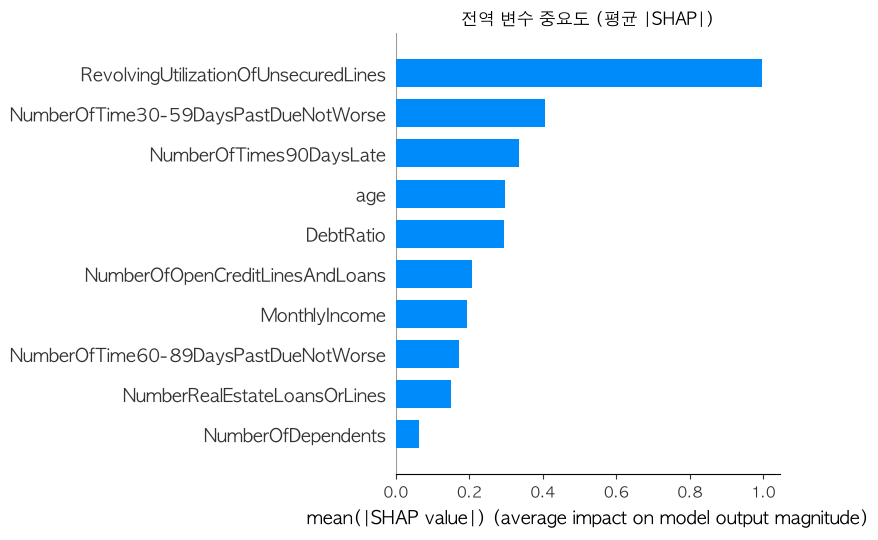

In [10]:
shap.summary_plot(shap_values, X_holdout, plot_type="bar", show=False)
plt.title("전역 변수 중요도 (평균 |SHAP|)")
plt.tight_layout()
plt.show()


In [11]:
# 개별 고객 1명: 홀드아웃에서 예측 확률이 가장 높은 고객(가장 위험도가 높게 나온 사례)
top_risk_pos = np.argmax(xgb_proba)
customer_id = X_holdout.index[top_risk_pos]

customer_shap = pd.Series(shap_values[top_risk_pos], index=feature_cols)
customer_values = X_holdout.iloc[top_risk_pos]

customer_report = pd.DataFrame(
    {
        "값": customer_values,
        "SHAP 기여도": customer_shap,
    }
).sort_values("SHAP 기여도", key=abs, ascending=False)

print(f"고객 인덱스: {customer_id}")
print(f"예측 부실 확률: {xgb_proba[top_risk_pos]:.2%}")
print(f"실제 타깃: {y_holdout.loc[customer_id]}")
print()
print("상위 기여 변수 (절댓값 기준 정렬, 양수=위험 증가, 음수=위험 감소):")
customer_report.head(6)


고객 인덱스: 10826
예측 부실 확률: 99.25%
실제 타깃: 1

상위 기여 변수 (절댓값 기준 정렬, 양수=위험 증가, 음수=위험 감소):


,값,SHAP 기여도
NumberOfTimes90DaysLate,3.000000,1.737012
DebtRatio,1.410140,0.783327
NumberOfTime30-59DaysPastDueNotWorse,3.000000,0.747989
NumberOfTime60-89DaysPastDueNotWorse,1.000000,0.704840
RevolvingUtilizationOfUnsecuredLines,0.877403,0.360720
NumberOfOpenCreditLinesAndLoans,12.000000,0.319739


## 7. 임계값별 승인율 vs 승인자 부실률

XGBoost 예측 확률(부실 확률)이 임계값보다 **낮으면 승인**한다고 가정한다.
임계값을 낮출수록 보수적(승인율 낮음, 부실률 낮음), 높일수록 공격적(승인율 높음, 부실률 높음)이다.


In [12]:
with timer("임계값 스윕"):
    thresholds = np.arange(0.05, 1.0, 0.05)
    rows = []
    for t in thresholds:
        approved = xgb_proba < t
        approval_rate = approved.mean()
        if approved.sum() == 0:
            bad_rate = np.nan
        else:
            bad_rate = y_holdout.values[approved].mean()
        rows.append((round(t, 2), approval_rate, bad_rate))

threshold_table = pd.DataFrame(rows, columns=["임계값(부실확률 컷)", "승인율", "승인자 부실률"])
threshold_table["승인율"] = threshold_table["승인율"].map(lambda x: f"{x:.1%}")
threshold_table["승인자 부실률"] = threshold_table["승인자 부실률"].map(
    lambda x: f"{x:.2%}" if pd.notna(x) else "-"
)
threshold_table


[임계값 스윕] 0.00초


,임계값(부실확률 컷),승인율,승인자 부실률
0,0.05,20.0%,0.73%
1,0.10,35.5%,0.87%
2,0.15,45.9%,1.04%
3,0.20,54.1%,1.22%
4,0.25,60.1%,1.46%
5,0.30,65.0%,1.58%
6,0.35,69.4%,1.87%
7,0.40,73.2%,2.09%
8,0.45,76.6%,2.25%
9,0.50,79.7%,2.51%


## 8. 단계별 실행 시간 요약

In [13]:
timing_df = pd.DataFrame(
    [(k, f"{v:.2f}초") for k, v in timings.items()], columns=["단계", "소요 시간"]
)
total = sum(timings.values())
print(f"전체 합계: {total:.2f}초")
timing_df


전체 합계: 0.95초


,단계,소요 시간
0,데이터 로드,0.05초
1,데이터 점검,0.00초
2,전처리,0.03초
3,로지스틱 회귀 학습,0.03초
4,XGBoost 학습,0.19초
5,SHAP 계산,0.65초
6,임계값 스윕,0.00초


## 9. 결론

- 파이프라인이 전 구간 끝까지 실행되는지: 위 셀이 모두 에러 없이 실행되면 확인 완료.
- 로지스틱 회귀 대비 XGBoost AUC 개선 폭이 실질적인지: 위 "4번" 표 참고.
- SHAP 계산이 이 데이터 규모(약 15만 행)에서 감당 가능한 시간인지: "8번" 표의 SHAP 계산 시간 참고.
- 임계값 표가 실제로 승인율-부실률 트레이드오프를 보여주는지: "7번" 표 참고.

결과 요약은 `docs/spike-feasibility.md`에 별도로 정리한다.
